<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/hierachical_clustering_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          **HIERARCHICAL CLUSTERING ASSIGNMENT**


Problem Statement

This assignment aims to utilize Hierarchical Clustering algorithms to analyze given datasets, extracting meaningful insights from their underlying structures. By exploring the datasets and employing Hierarchical Clustering techniques, students are expected to categorize the data into distinct clusters. The assignment emphasizes parameter tuning for optimal clustering results and requires interpretation of the clustering outcomes to derive valuable insights.

Guidelines

1. Foundational Knowledge
   - Understand the principles of clustering and how data can be segmented into clusters.
   - Familiarize yourself with Hierarchical Clustering algorithms and comprehend their principles and advantages.
   - Recognize different linkage methods (e.g., Ward, complete, average) and their impact on Hierarchical Clustering.

2. Data Exploration
   - Analyze the dataset's structure and characteristics using various exploratory techniques such as scatter plots, boxplots, heatmaps, etc.
   - Gain insights into the dataset's attributes to guide the clustering process.

3. Preprocessing and Parameter Selection
   - Standardize features if required, as Hierarchical Clustering can be sensitive to feature scales.
   - Select appropriate linkage methods and distance metrics based on data exploration.

4. Hierarchical Clustering
   - Implement Hierarchical Clustering algorithms using chosen parameters and methods.
   - Adjust linkage methods and other parameters to optimize clustering efficiency.

5. Cluster Analysis
   - Analyze resulting clusters to understand their attributes and characteristics.
   - Evaluate unclustered data points to derive conclusions about the dataset.
   - Compare findings with initial exploratory analysis to reinforce insights.







Step-by-Step Approach to Hierarchical Clustering

1. Setup and Data Preparation
   - Import necessary libraries: pandas, matplotlib, and Scikit-Learn.
   - Load the dataset for clustering.
   - Preprocess the data, ensuring standardized features if necessary.

2. Hierarchical Clustering Parameters
   - Choose appropriate linkage methods (e.g., Ward, complete, average).
   - Define distance metrics suitable for the dataset.

3. Performing Hierarchical Clustering
   - Initialize the Hierarchical Clustering model with selected parameters.
   - Apply the model on the prepared data.

4. Result Analysis
   - Examine cluster labels and interpret the clusters formed.
   - Visualize clusters to differentiate them using appropriate markers/colors.

5. Evaluation and Iteration
   - Compare Hierarchical Clustering results to any available actual clusters.
   - Adjust parameters (linkage methods, distance metrics) if clustering results are unsatisfactory.

6. Interpretation and Conclusion
   - Understand cluster patterns and distinctions.
   - Decide on handling noise or outliers, if any.

Links to Datasets for the Assignment

- Customer Clustering
https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?select=segmentation+data.csv
- Credit Card Dataset for Clustering
https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data
- Mall Customer Segmentation Data
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


We are going to work on Customer Clustering https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?select=segmentation+data.csv

In [1]:
## Loading important libraries
import pandas as pd ## for Data Manipulation and DataFrame Creation
import numpy as np## For numerical calculation
import matplotlib.pyplot as plt ##for Basic Data Plotting
import seaborn as sns ##for advanced plotting
import warnings
warnings.filterwarnings('ignore')

In [2]:
## loading the data
df=pd.read_csv('/content/segmentation data.csv')

In [3]:
df

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0


Details of features of data

ID -Identification of the person.

Sex-Gender of the person

Marital_status-marital status of the person.

Age-Age of the person.

Education-education of the person.

Income-income of the person

Occupation-Occupation of the person.

Settlement_size-Settlement size can be categorized into small, medium, or large cities


Since there is no output label, it is an unsupervised machine learning problem, and we will use a hierarchical clustering algorithm on that to cluster the segments of the customers.

## Data summerisation

In [4]:
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [5]:
df.shape

(2000, 8)

In [6]:
df.columns

Index(['ID', 'Sex', 'Marital status', 'Age', 'Education', 'Income',
       'Occupation', 'Settlement size'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [8]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [9]:
##Getting an idea about the null values.
df.isnull().sum()

,0
ID,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0


There are no null values in the dataset. It is a clean dataset.

In [10]:
## Since id is of no use so dropping it
df.drop(['ID'],axis=1,inplace=True)

In [11]:
df.head(1)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2


In [12]:
## Getting an idea about categorical and features column.

# Explicitly define categorical columns that are integer-encoded
Categorical_col = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']

# Numerical columns are the remaining columns that are not categorical
Numerical_col = [col for col in df.columns if col not in Categorical_col]

print(f'Numerical_col: {Numerical_col}')
print(f'Categorical_col: {Categorical_col}')

Numerical_col: ['Age', 'Income']
Categorical_col: ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']


Data Visualisation

In [13]:
df.head(2)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2


Since the numerical column is both numerical and continuous, we will apply a histogram on that.

### Histograms for Numerical Columns: Age and Income (with KDE)

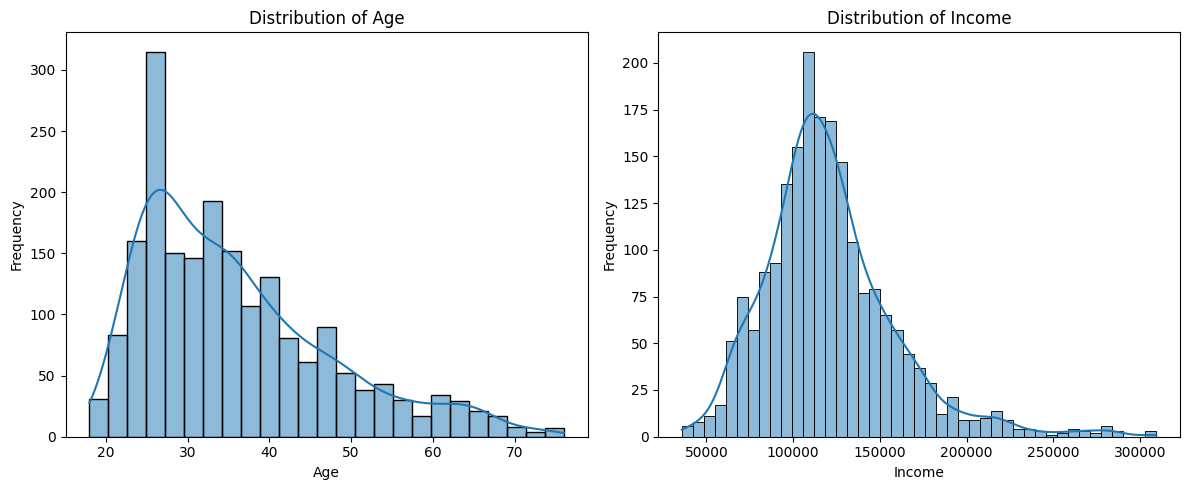

In [14]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(Numerical_col):
    plt.subplot(1, len(Numerical_col), i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The above age histogram shows us that the distribution is right skewed, meaning that the most frequent age groups of the customer are of less age. The income distribution also tells that it is a right-skewed distribution for income, meaning that the larger number of customers is in the lower middle income and fewer in the very high income bracket.

### Bar Plots for Categorical Columns

Let's visualize the distribution of each categorical feature using bar plots.

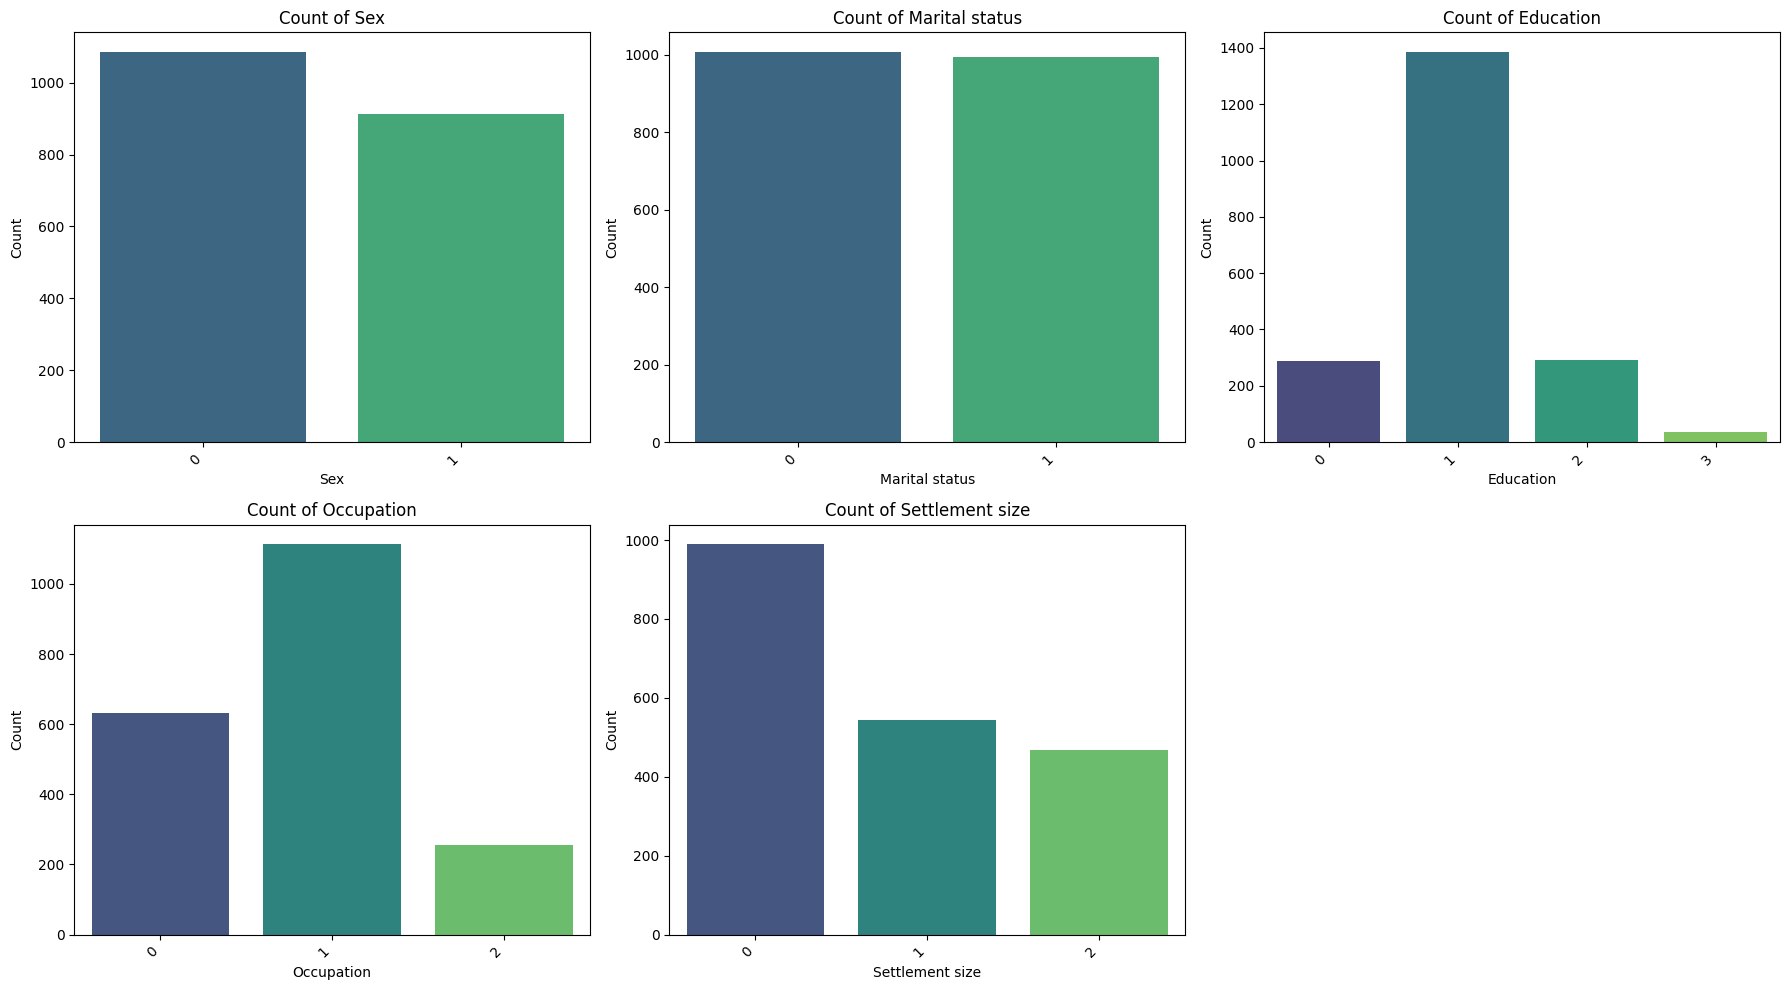

In [15]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(Categorical_col):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed, 2 rows, 3 columns
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

The bar graph shows that females have more count than males. Marital status is the same for women and men, and education is higher for the middle level. Most people live in a zero settlement size.

### Box Plots for Numerical Columns: Age and Income

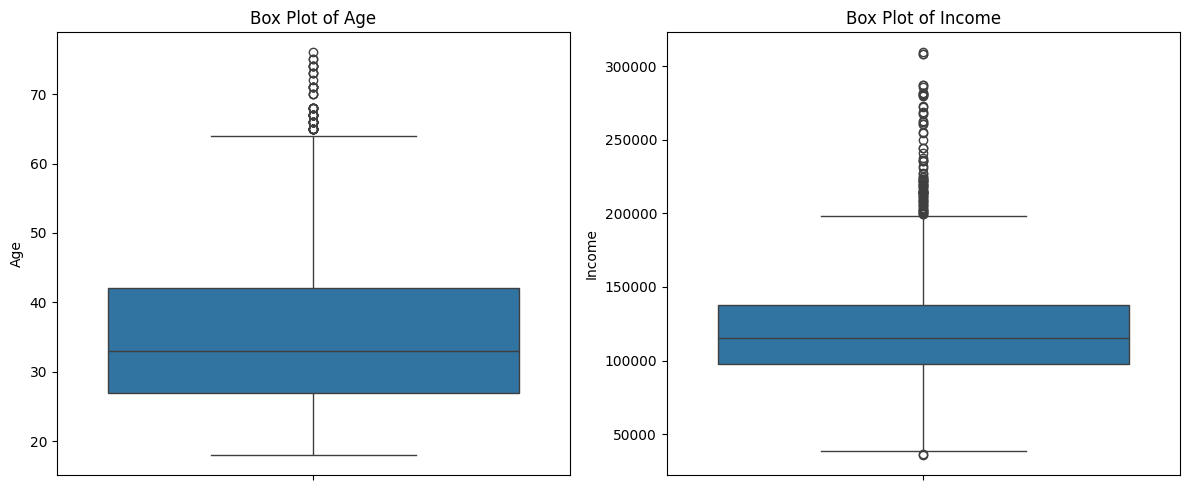

In [16]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(Numerical_col):
    plt.subplot(1, len(Numerical_col), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In an income box plot, the median is in the center of the box, so it means it is equally distributed data, as many dots are there, so it means many outliers are there.

relationship between age and income, since both are
numerical columns, so we will see the scatter plot
 with regression line.

### Scatter Plot with Regression Line: Age vs. Income

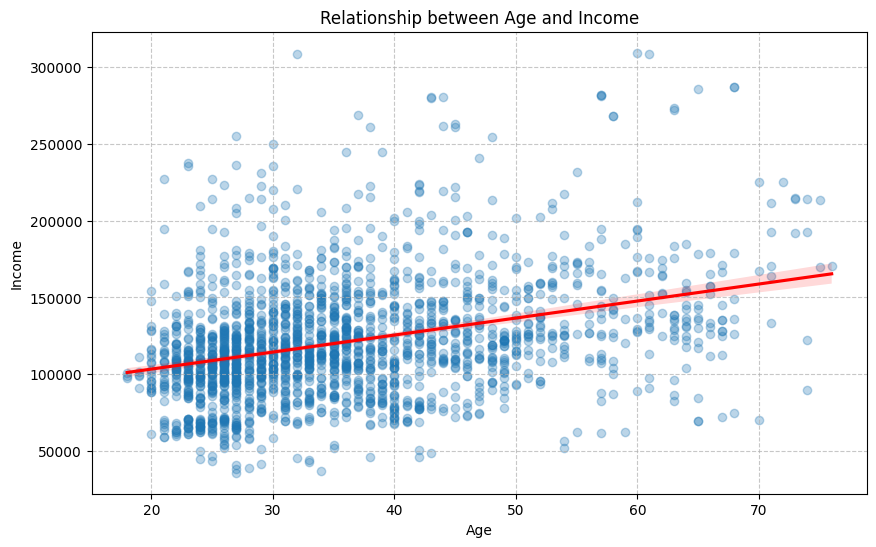

In [17]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='Income', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Age and Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

There is a linear relationship between age and income. As the age increases, income increases.

The relationship between education and income and occupation and income, since one is numerical and one is categorical, so we will use bar plot and violin flow plot for that.

### Relationship between Education and Income

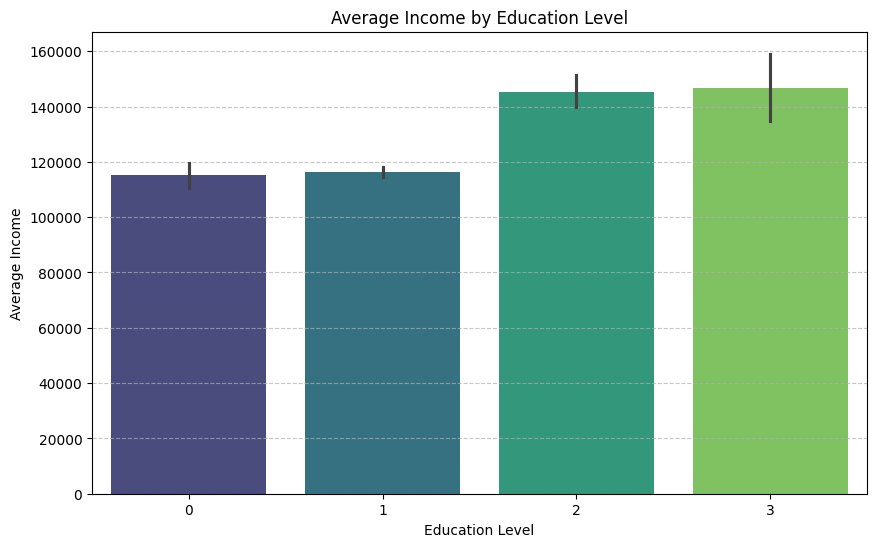

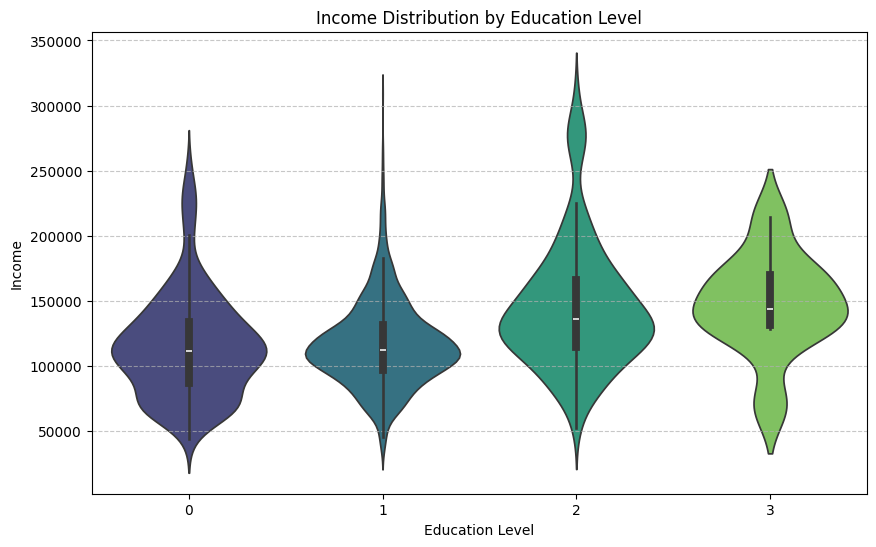

In [18]:
# Bar Plot: Education vs. Income
plt.figure(figsize=(10, 6))
sns.barplot(x='Education', y='Income', data=df, palette='viridis')
plt.title('Average Income by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Violin Plot: Education vs. Income
plt.figure(figsize=(10, 6))
sns.violinplot(x='Education', y='Income', data=df, palette='viridis')
plt.title('Income Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Higher the education. Higher the income.

### Relationship between Occupation and Income

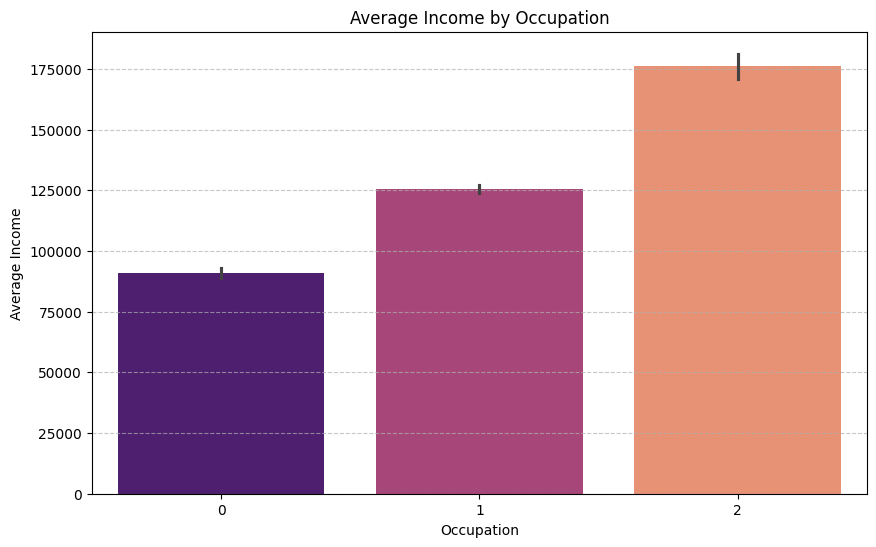

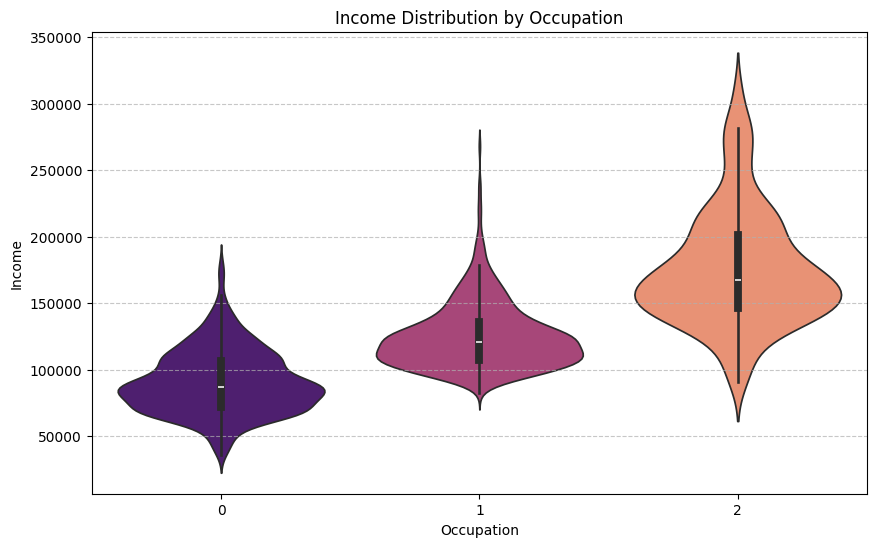

In [19]:
# Bar Plot: Occupation vs. Income
plt.figure(figsize=(10, 6))
sns.barplot(x='Occupation', y='Income', data=df, palette='magma')
plt.title('Average Income by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Violin Plot: Occupation vs. Income
plt.figure(figsize=(10, 6))
sns.violinplot(x='Occupation', y='Income', data=df, palette='magma')
plt.title('Income Distribution by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Relationship between the all categorical columns cross step plus seatbelt

### Relationships Between Categorical Columns

Let's visualize the pairwise relationships between some of the categorical features to understand their interplay.

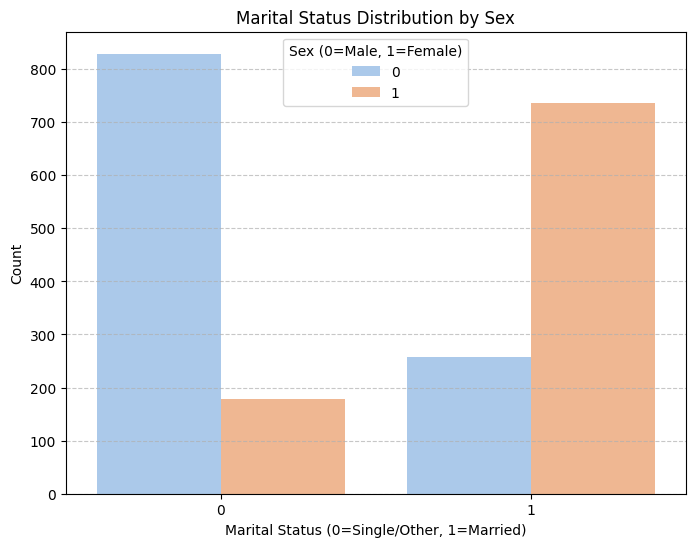

In [20]:
# Relationship between Marital status and Sex
plt.figure(figsize=(8, 6))
sns.countplot(x='Marital status', hue='Sex', data=df, palette='pastel')
plt.title('Marital Status Distribution by Sex')
plt.xlabel('Marital Status (0=Single/Other, 1=Married)')
plt.ylabel('Count')
plt.legend(title='Sex (0=Male, 1=Female)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

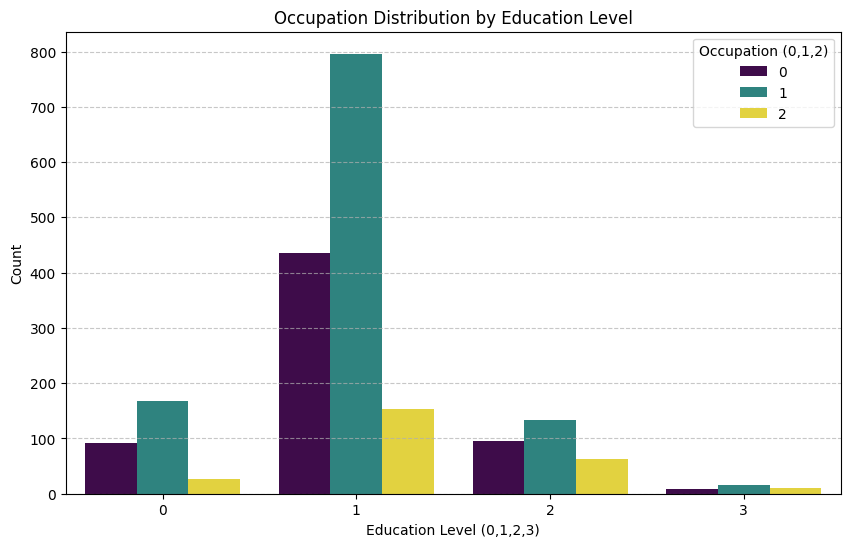

In [21]:
# Relationship between Education and Occupation
plt.figure(figsize=(10, 6))
sns.countplot(x='Education', hue='Occupation', data=df, palette='viridis')
plt.title('Occupation Distribution by Education Level')
plt.xlabel('Education Level (0,1,2,3)')
plt.ylabel('Count')
plt.legend(title='Occupation (0,1,2)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualizing Feature Correlations with a Heatmap

A heatmap of the correlation matrix helps to quickly grasp the linear relationships between all numerical and encoded categorical features in the dataset. Values close to 1 or -1 indicate strong positive or negative correlations, respectively, while values close to 0 indicate weak or no linear correlation.

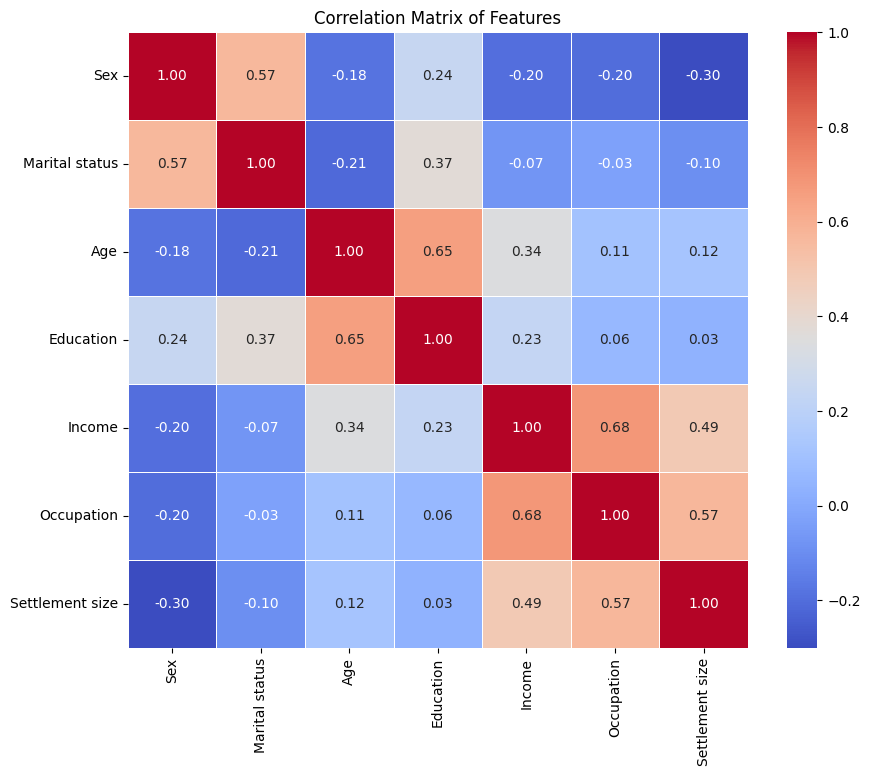

In [22]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

The Correlational Graph shows that income and occupation are positively correlated. As the occupation increased, income increased similarly. For the income and age, as the age increased, income increased.

### Data Preprocessing for Hierarchical Clustering: Standardization

Before applying hierarchical clustering, it's essential to scale the data. Clustering algorithms often rely on distance metrics, and features with larger values can disproportionately influence these distances. Standardization (or Z-score normalization) transforms the data to have a mean of 0 and a standard deviation of 1, ensuring all features contribute equally.

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Create a copy of the DataFrame to avoid modifying the original
df_scaled = df.copy()

# Apply StandardScaler to the numerical columns
df_scaled[Numerical_col] = scaler.fit_transform(df_scaled[Numerical_col])

print("Scaled DataFrame head:")
print(df_scaled.head())

print("\nDescriptive statistics of scaled numerical columns:")
print(df_scaled[Numerical_col].describe())

Scaled DataFrame head:
   Sex  Marital status       Age  Education    Income  Occupation  \
0    0               0  2.653614          2  0.097524           1   
1    1               1 -1.187132          1  0.782654           1   
2    0               0  1.117316          1 -0.833202           0   
3    0               0  0.775916          1  1.328386           1   
4    0               0  1.458716          1  0.736932           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  

Descriptive statistics of scaled numerical columns:
                Age        Income
count  2.000000e+03  2.000000e+03
mean   9.059420e-17  1.563194e-16
std    1.000250e+00  1.000250e+00
min   -1.528532e+00 -2.234225e+00
25%   -7.603825e-01 -6.113281e-01
50%   -2.482829e-01 -1.418903e-01
75%    5.198664e-01  4.492952e-01
max    3.421764e+00  4.945225e+00


In [24]:
## Checking and Removing Outliers (IQR Method)

Outliers can disproportionately influence clustering algorithms by skewing distance calculations. We'll use the Interquartile Range (IQR) method to identify and remove outliers from our numerical features ('Age' and 'Income').

The IQR method defines outliers as any data point falling below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$, where $Q1$ is the first quartile, $Q3$ is the third quartile, and $IQR = Q3 - Q1$.

SyntaxError: unterminated string literal (detected at line 3) (3093334212.py, line 3)

In [25]:
df_no_outliers = df_scaled.copy()

for col in Numerical_col:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_no_outliers[(df_no_outliers[col] < lower_bound) | (df_no_outliers[col] > upper_bound)]
    print(f"Outliers in {col}:\n{outliers[[col]]}")

    # Remove outliers
    df_no_outliers = df_no_outliers[~((df_no_outliers[col] < lower_bound) | (df_no_outliers[col] > upper_bound))]

print(f"\nOriginal DataFrame shape: {df_scaled.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")

df_scaled = df_no_outliers.copy()
print("\nHead of DataFrame after outlier removal:")
display(df_scaled.head())

Outliers in Age:
           Age
0     2.653614
75    2.568265
137   2.568265
163   2.909664
179   2.482915
186   3.251064
187   2.738964
213   2.568265
330   3.336414
430   3.251064
438   2.482915
536   3.336414
554   2.653614
606   3.251064
624   2.482915
723   2.568265
756   3.251064
774   2.568265
779   2.653614
807   2.482915
846   2.738964
883   2.482915
917   2.738964
1001  2.568265
1004  2.482915
1005  3.165714
1017  2.738964
1019  3.165714
1023  2.482915
1026  2.482915
1027  3.080364
1029  2.738964
1035  2.909664
1036  2.482915
1053  2.738964
1062  3.165714
1063  2.568265
1064  3.421764
1075  2.653614
1076  2.995014
1088  2.653614
1090  2.995014
1093  2.482915
1096  2.482915
1099  2.995014
1106  2.568265
1143  2.653614
1276  2.738964
1297  2.995014
1316  2.653614
1393  2.653614
1397  2.995014
1428  2.568265
1432  2.909664
1456  2.482915
1572  2.653614
1576  2.653614
Outliers in Income:
        Income
18    3.700792
56    2.142312
63    2.793505
87    3.152646
95    3.868459
...

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
1,1,1,-1.187132,1,0.782654,1,2
2,0,0,1.117316,1,-0.833202,0,0
3,0,0,0.775916,1,1.328386,1,1
4,0,0,1.458716,1,0.736932,1,1
5,0,0,-0.077583,1,0.627140,0,0


a summary of the operation:

Outliers in Age: 58 outliers were identified based on the IQR method.

Outliers in Income: 75 outliers were identified based on the IQR method.

Original DataFrame Shape: The DataFrame df_scaled initially had 2000 rows and 8 columns.
DataFrame Shape After Outlier Removal: After removing the outliers, the DataFrame now has 1868 rows and 8 columns. This means a total of 132 rows (data points) were removed. (Note: Some rows might have been outliers in both 'Age' and 'Income', which is why 58+75 > 132)



In [ ]:
##Feature correlation matrix

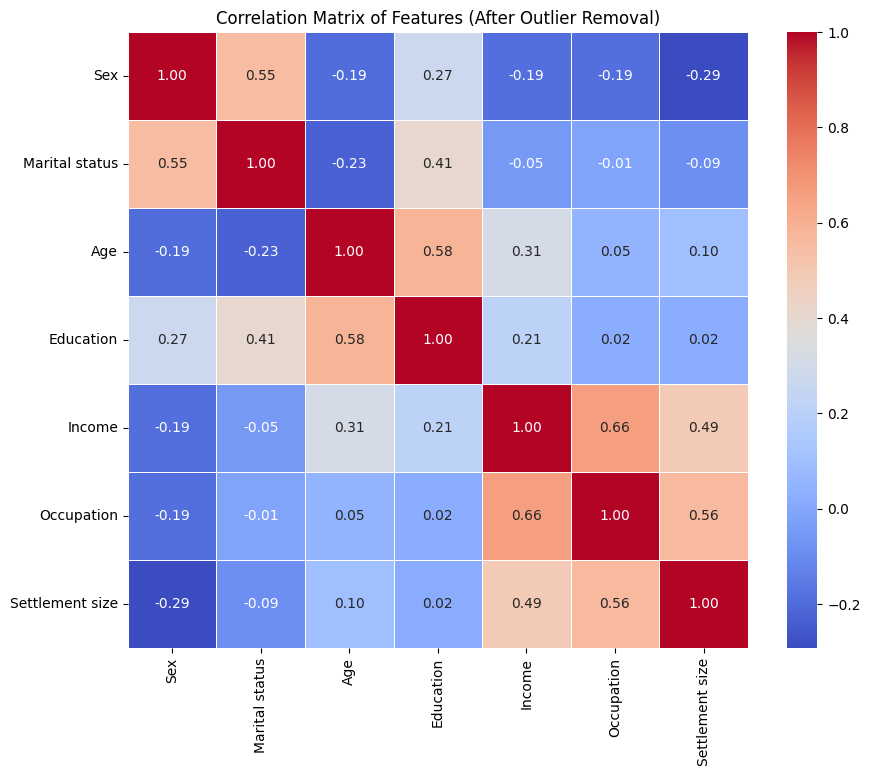

In [26]:
# Calculate the correlation matrix using the cleaned and scaled DataFrame
correlation_matrix_cleaned = df_scaled.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features (After Outlier Removal)')
plt.show()

In [28]:
##PCA Step by Step (From Scratch!) Step 1: Center the Data
X = df_scaled.values # Define X from the preprocessed and scaled DataFrame
X_centered = X - X.mean(axis=0)
print(f"Mean after centering (should be ~0): {X_centered.mean(axis=0).round(10)}")

Mean after centering (should be ~0): [-0. -0.  0. -0. -0. -0.  0.]


In [ ]:
##covarience matrix

In [29]:
# Calculate the covariance matrix
covariance_matrix = np.cov(X_centered, rowvar=False)

print("Covariance Matrix:")
display(pd.DataFrame(covariance_matrix, columns=df.columns, index=df.columns))

Covariance Matrix:


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Sex,0.249102,0.138327,-0.085138,0.073675,-0.073647,-0.057884,-0.117294
Marital status,0.138327,0.250116,-0.102628,0.110905,-0.021346,-0.004351,-0.034602
Age,-0.085138,-0.102628,0.782304,0.281898,0.214056,0.025414,0.068239
Education,0.073675,0.110905,0.281898,0.297748,0.088763,0.006812,0.006858
Income,-0.073647,-0.021346,0.214056,0.088763,0.604907,0.311954,0.305664
Occupation,-0.057884,-0.004351,0.025414,0.006812,0.311954,0.370273,0.272466
Settlement size,-0.117294,-0.034602,0.068239,0.006858,0.305664,0.272466,0.643878


Step 3: Calculate Eigenvalues and Eigenvectors
Eigenvalues and eigenvectors are crucial for PCA. Eigenvectors represent the principal components (new axes), and eigenvalues represent the magnitude of variance along those axes.

In [30]:
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# numpy.linalg.eigh returns eigenvalues in ASCENDING order
# We want DESCENDING (largest first)
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Eigenvalues (variance explained by each PC):")
for i, ev in enumerate(eigenvalues):
    print(f"  PC{i+1}: {ev:.4f}  ({ev/eigenvalues.sum()*100:.1f}% of total variance)")

Eigenvalues (variance explained by each PC):
  PC1: 1.2936  (40.4% of total variance)
  PC2: 0.8296  (25.9% of total variance)
  PC3: 0.4708  (14.7% of total variance)
  PC4: 0.3016  (9.4% of total variance)
  PC5: 0.1313  (4.1% of total variance)
  PC6: 0.1125  (3.5% of total variance)
  PC7: 0.0589  (1.8% of total variance)


Step 4: How Many Components Do We Need?
We look at the "explained variance ratio" — the fraction of total variance captured by each PC.

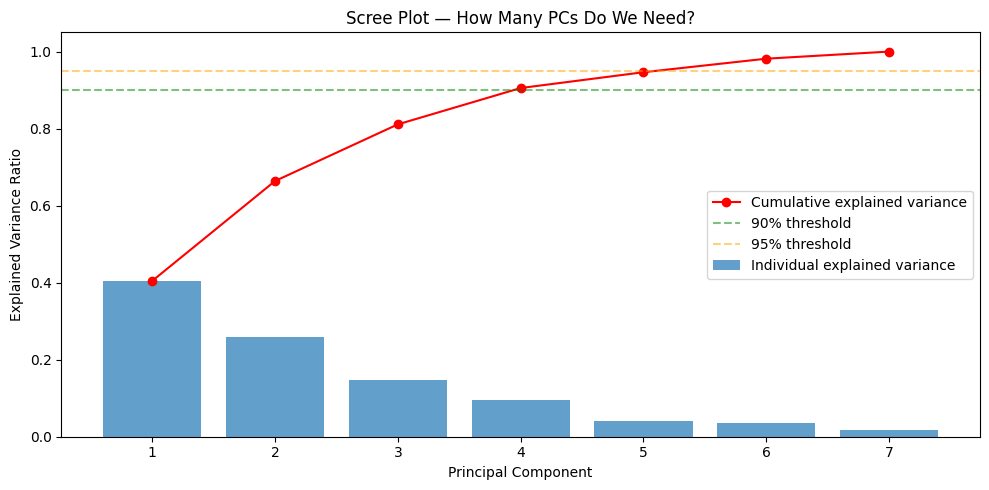


First 2 PCs explain 66.4% of variance
First 3 PCs explain 81.1% of variance


In [31]:
explained_var_ratio = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var_ratio)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(eigenvalues)+1), explained_var_ratio, alpha=0.7,
       label="Individual explained variance")
ax.plot(range(1, len(eigenvalues)+1), cumulative_var, "ro-",
        label="Cumulative explained variance")
ax.axhline(0.9, color="green", linestyle="--", alpha=0.5, label="90% threshold")
ax.axhline(0.95, color="orange", linestyle="--", alpha=0.5, label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot — How Many PCs Do We Need?")
ax.set_xticks(range(1, len(eigenvalues)+1))
ax.legend()
plt.tight_layout()
plt.savefig("fig_08_scree_plot.png", bbox_inches="tight")
plt.show()

print(f"\nFirst 2 PCs explain {cumulative_var[1]*100:.1f}% of variance")
print(f"First 3 PCs explain {cumulative_var[2]*100:.1f}% of variance")


Step 5: Project Data onto Principal Components
This is the transformation: X_pca = X_centered @ eigenvectors Each row gets new coordinates in the PC space.



In [32]:
# Project onto all 5 PCs
X_pca = X_centered @ eigenvectors

# We'll primarily use the first 2 PCs for visualization
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

print(f"PC1 range: [{pc1.min():.2f}, {pc1.max():.2f}]")
print(f"PC2 range: [{pc2.min():.2f}, {pc2.max():.2f}]")


PC1 range: [-2.27, 3.21]
PC2 range: [-2.87, 2.26]


##Visalisation

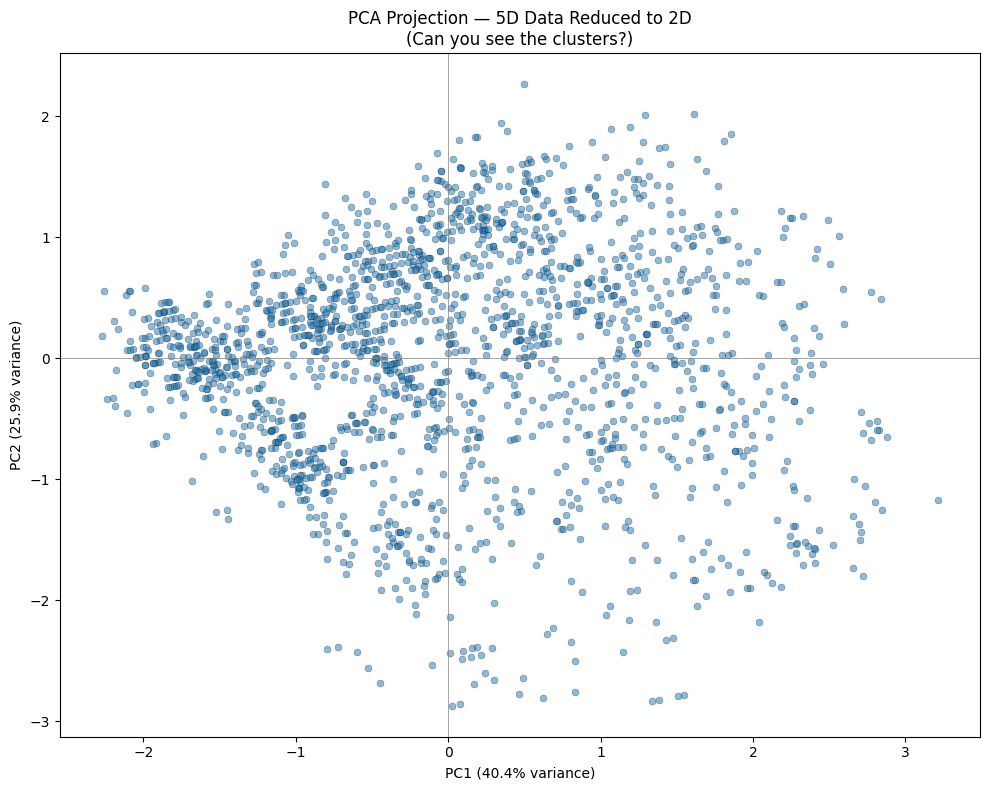

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pc1, pc2, alpha=0.5, s=25, edgecolors="k", linewidths=0.3)
ax.set_xlabel(f"PC1 ({explained_var_ratio[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var_ratio[1]*100:.1f}% variance)")
ax.set_title("PCA Projection — 5D Data Reduced to 2D\n(Can you see the clusters?)")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.savefig("fig_09_pca_projection.png", bbox_inches="tight")
plt.show()


PCA Loadings (feature contributions to each PC):
                   PC1    PC2    PC3    PC4    PC5    PC6    PC7
Sex             -0.154 -0.065  0.540 -0.051  0.148 -0.810  0.009
Marital status  -0.078  0.014  0.635 -0.170 -0.062  0.430 -0.610
Age              0.462 -0.756 -0.191 -0.093 -0.104 -0.172 -0.360
Education        0.168 -0.374  0.442 -0.205 -0.093  0.296  0.706
Income           0.577  0.138  0.219  0.578  0.509  0.081  0.001
Occupation       0.369  0.302  0.146  0.245 -0.816 -0.162  0.012
Settlement size  0.509  0.417 -0.065 -0.723  0.175 -0.096 -0.007


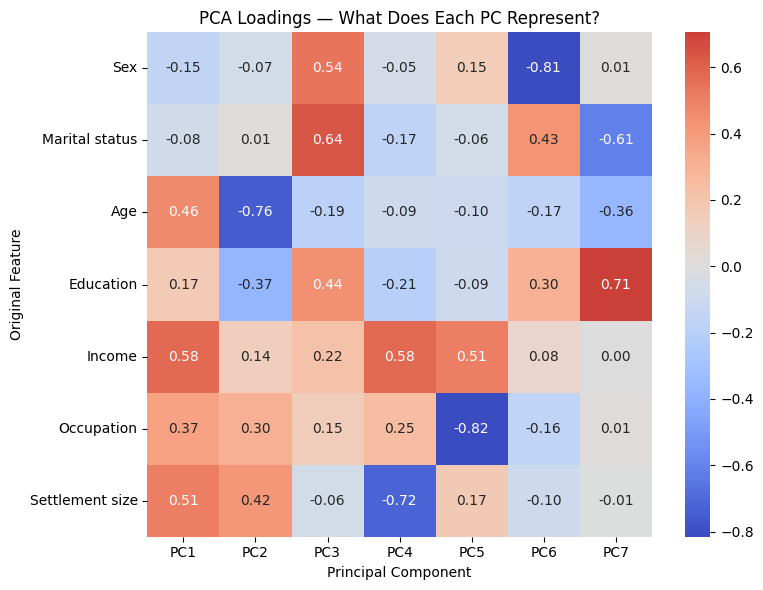


=== Interpreting the Loadings ===
PC1: Most influenced by Income (positively, weight=0.58)
PC2: Most influenced by Age (negatively, weight=-0.76)
PC3: Most influenced by Marital status (positively, weight=0.64)
PC4: Most influenced by Settlement size (negatively, weight=-0.72)
PC5: Most influenced by Occupation (negatively, weight=-0.82)
PC6: Most influenced by Sex (negatively, weight=-0.81)
PC7: Most influenced by Education (positively, weight=0.71)


In [34]:
feature_cols = df.columns # Define feature_cols from the original DataFrame

loadings = pd.DataFrame(
    eigenvectors,
    columns=[f"PC{i+1}" for i in range(len(eigenvalues))],
    index=feature_cols
)
print("PCA Loadings (feature contributions to each PC):")
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax, square=True)
ax.set_title("PCA Loadings — What Does Each PC Represent?")
ax.set_ylabel("Original Feature")
ax.set_xlabel("Principal Component")
plt.tight_layout()
plt.savefig("fig_10_pca_loadings.png", bbox_inches="tight")
plt.show()

# Interpretation guide
print("\n=== Interpreting the Loadings ===")
for pc in loadings.columns:
    top_feat = loadings[pc].abs().idxmax()
    top_val = loadings[pc][top_feat]
    direction = "positively" if top_val > 0 else "negatively"
    print(f"{pc}: Most influenced by {top_feat} ({direction}, weight={top_val:.2f})")

### Performing Hierarchical Clustering and Visualizing with a Dendrogram

After standardizing the numerical features, we can now apply Hierarchical Clustering. A dendrogram will help us visualize the clustering process and decide on the optimal number of clusters.

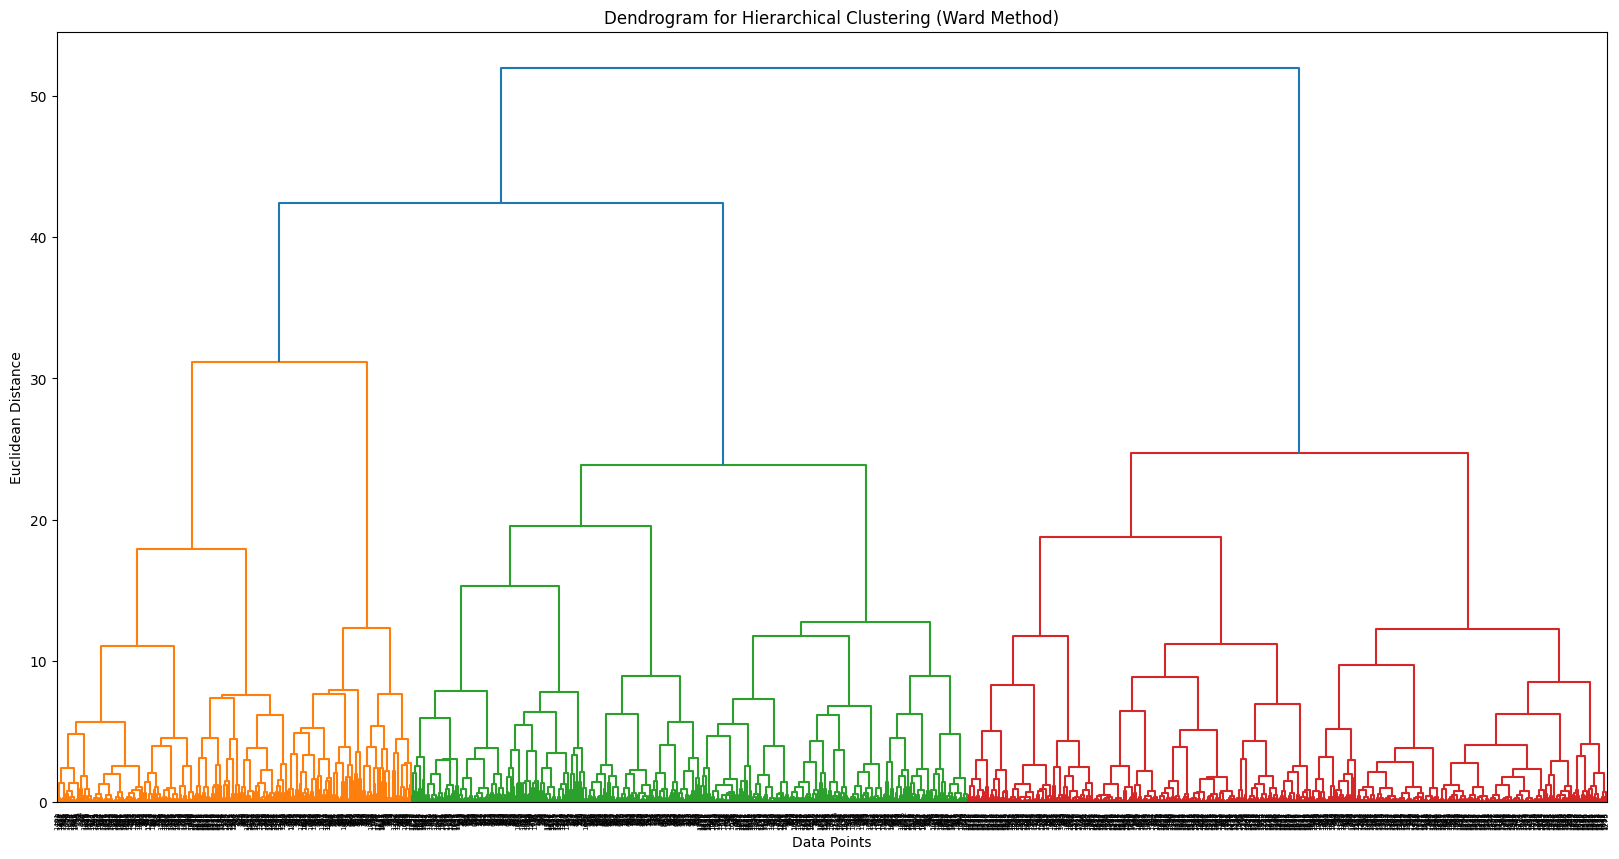

In [35]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Prepare the data for clustering (using the scaled DataFrame with all features)
X = df_scaled.values

# Generate the linkage matrix using 'ward' method
linked_data = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering (Ward Method)')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()


Step7: Training the dataset and predicting the result using the best Optimal no of clusters=5

In [36]:
from sklearn.cluster import AgglomerativeClustering
Hierarchical_model=AgglomerativeClustering(n_clusters=5,linkage='ward')
y=Hierarchical_model.fit_predict(X)

In [37]:
y

array([0, 1, 0, ..., 2, 2, 2])

## Calculating the accuracy score

In [38]:
from sklearn.metrics import silhouette_score

In [39]:
score=silhouette_score(X,y)

In [40]:
score

np.float64(0.18632213424113664)

### Evaluating Different Numbers of Clusters using Silhouette Score

To find a more optimal number of clusters, we can iterate through a range of `n_clusters` values and calculate the silhouette score for each. The silhouette score measures how similar an object is to its own cluster compared to other clusters, with a higher score indicating better-defined clusters.

Number of clusters: 2, Silhouette Score: 0.2034
Number of clusters: 3, Silhouette Score: 0.2323
Number of clusters: 4, Silhouette Score: 0.2212
Number of clusters: 5, Silhouette Score: 0.1863
Number of clusters: 6, Silhouette Score: 0.1914
Number of clusters: 7, Silhouette Score: 0.2094
Number of clusters: 8, Silhouette Score: 0.2227
Number of clusters: 9, Silhouette Score: 0.2325
Number of clusters: 10, Silhouette Score: 0.2380


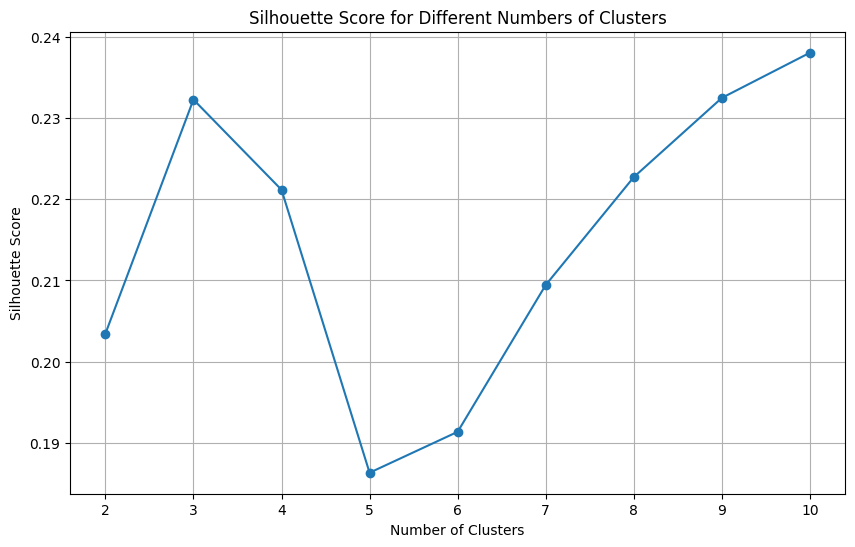

In [41]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
max_clusters = 10 # You can adjust this range

for n_clusters in range(2, max_clusters + 1):
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"Number of clusters: {n_clusters}, Silhouette Score: {score:.4f}")

# Plotting the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_clusters + 1))
plt.grid(True)
plt.show()

### Applying Hierarchical Clustering with Optimal Clusters and Visualizing on PCA

Based on the silhouette score analysis, we will now apply `AgglomerativeClustering` with 10 clusters and then visualize these clusters on the scatter plot of the first two principal components (PC1 and PC2).

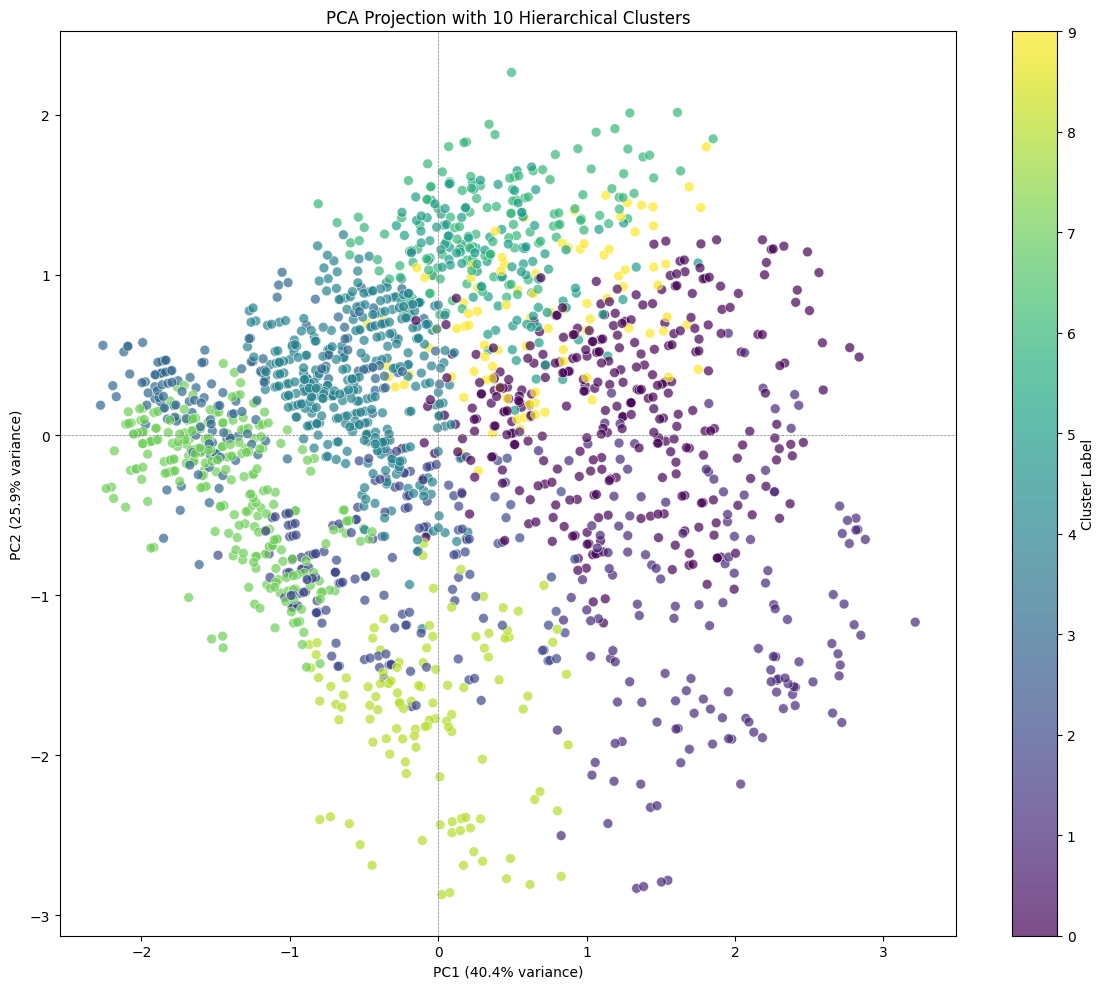

In [42]:
# Re-apply Agglomerative Clustering with the optimal number of clusters (10)
optimal_n_clusters = 10
hierarchical_model_optimal = AgglomerativeClustering(n_clusters=optimal_n_clusters, linkage='ward')
cluster_labels_optimal = hierarchical_model_optimal.fit_predict(X)

# Create a scatter plot of PC1 vs PC2, colored by the new cluster labels
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(pc1, pc2, c=cluster_labels_optimal, cmap='viridis', alpha=0.7, s=50, edgecolors='w', linewidths=0.5)

ax.set_xlabel(f"PC1 ({explained_var_ratio[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var_ratio[1]*100:.1f}% variance)")
ax.set_title(f"PCA Projection with {optimal_n_clusters} Hierarchical Clusters")
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

# Add a colorbar/legend
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label')

plt.tight_layout()
plt.show()

### Analyzing Cluster Characteristics

To understand the distinct profiles of the identified clusters, we will calculate the mean of each feature for every cluster. This will help us interpret the segments of customers formed by the hierarchical clustering.

In [44]:
# Add the cluster labels to the scaled DataFrame for easier analysis
df_clustered_optimal = df_scaled.copy()
df_clustered_optimal['Cluster'] = cluster_labels_optimal

# Group by cluster and calculate the mean of each feature
cluster_means_optimal = df_clustered_optimal.groupby('Cluster').mean()

print("Mean values of features for each cluster (Optimal 10 Clusters):")
display(cluster_means_optimal)

Mean values of features for each cluster (Optimal 10 Clusters):


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Cluster,,,,,,,
0,0.037152,0.043344,0.393559,1.000000,0.433535,1.185759,1.448916
1,0.493333,0.746667,1.457009,2.073333,0.721656,1.106667,1.293333
2,0.000000,0.000000,0.400582,1.000000,-0.449651,0.379518,0.000000
3,0.317881,0.000000,-0.769426,0.165563,-0.862567,0.245033,0.000000
4,0.845938,0.882353,-0.682683,0.980392,-0.273945,0.988796,0.347339
5,0.504425,0.955752,-0.724128,1.000000,-0.189496,1.097345,1.946903
6,0.000000,0.000000,-0.703901,0.000000,0.158333,1.110294,1.522059
7,0.851145,0.851145,-0.518015,1.000000,-0.967675,0.000000,0.000000
8,0.848214,0.642857,1.131033,1.839286,-0.365623,0.205357,0.000000


### Analyzing Cluster Characteristics on Original Unscaled Data

To understand the actual values and context of each cluster, we will now map the `cluster_labels_optimal` back to the original `df` (before scaling and outlier removal) and compute the mean of each feature for the 10 clusters.

In [46]:
# Create a temporary DataFrame with original data, but only for the rows that were used in clustering
# df_scaled has the correct indices after outlier removal, so we use those to select rows from the original df
df_original_clustered_subset = df.loc[df_scaled.index].copy()

# Add the cluster labels to this subset of the original DataFrame
df_original_clustered_subset['Cluster'] = cluster_labels_optimal

# Group by cluster and calculate the mean of each feature in the original scale
cluster_means_original = df_original_clustered_subset.groupby('Cluster').mean()

print("Mean values of features for each cluster (Optimal 10 Clusters - Original Data):")
display(cluster_means_original)

Mean values of features for each cluster (Optimal 10 Clusters - Original Data):


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Cluster,,,,,,,
0,0.037152,0.043344,40.520124,1.000000,137471.792570,1.185759,1.448916
1,0.493333,0.746667,52.980000,2.073333,148449.020000,1.106667,1.293333
2,0.000000,0.000000,40.602410,1.000000,103823.030120,0.379518,0.000000
3,0.317881,0.000000,26.894040,0.165563,88091.231788,0.245033,0.000000
4,0.845938,0.882353,27.910364,0.980392,110517.308123,0.988796,0.347339
5,0.504425,0.955752,27.424779,1.000000,113734.761062,1.097345,1.946903
6,0.000000,0.000000,27.661765,0.000000,126986.786765,1.110294,1.522059
7,0.851145,0.851145,29.839695,1.000000,84086.675573,0.000000,0.000000
8,0.848214,0.642857,49.160714,1.839286,107024.437500,0.205357,0.000000
